In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.plot_styles import *

In [2]:
input_filename = 'Output/grid_353x161_0.csv'

In [3]:
def GetSolutionDict(input_filename):
    # Read the first three lines to extract grid sizes
    with open(input_filename, 'r') as f:
        ndim = int(f.readline().strip().split('=')[1])
        ni = int(f.readline().strip().split('=')[1])
        nj = int(f.readline().strip().split('=')[1])
        nk = int(f.readline().strip().split('=')[1])
    
    df = pd.read_csv(input_filename, skiprows=4)
    data_dict = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    return data_dict

    
data_dict = GetSolutionDict(input_filename)

In [4]:
data_dict.keys()

dict_keys(['x', 'y', 'z'])

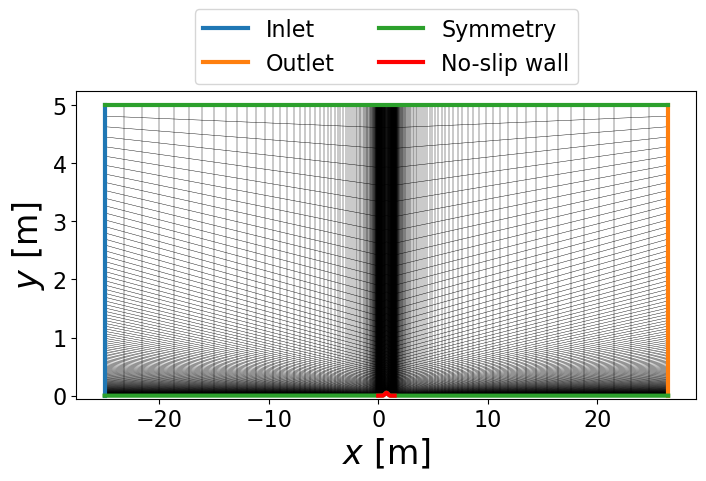

In [ ]:
ni,nj,nk = data_dict['x'].shape
figsize = (8, 4)
lw = 0.3
plt.figure(figsize=figsize)
skip = 1
for i in range(0, ni, skip):
    plt.plot(data_dict['x'][i,:,0], data_dict['y'][i,:,0], 'k-', linewidth=lw)
for j in range(0, nj, skip):
    plt.plot(data_dict['x'][:,j,0], data_dict['y'][:,j,0], 'k-', linewidth=lw)

plt.plot(data_dict['x'][0,:,0], data_dict['y'][0,:,0], 'C0-', linewidth=3, label='Inlet')
plt.plot(data_dict['x'][-1,:,0], data_dict['y'][-1,:,0], 'C1-', linewidth=3, label='Outlet')
plt.plot(data_dict['x'][:,0,0], data_dict['y'][:,0,0], 'C2-', linewidth=3, label='Symmetry')
plt.plot(data_dict['x'][:,-1,0], data_dict['y'][:,-1,0], 'C2-', linewidth=3)
plt.plot(data_dict['x'][97:257,0,0], data_dict['y'][97:257,0,0], 'r-', linewidth=3, label='No-slip wall')

plt.legend(ncol=2, bbox_to_anchor=(0.5, 1.3), loc='upper center')
plt.xlabel(r'$x$ [m]')
plt.ylabel(r'$y$ [m]')
plt.ylim(bottom=-.05)
plt.savefig('nasabump_grid.pdf', bbox_inches='tight')

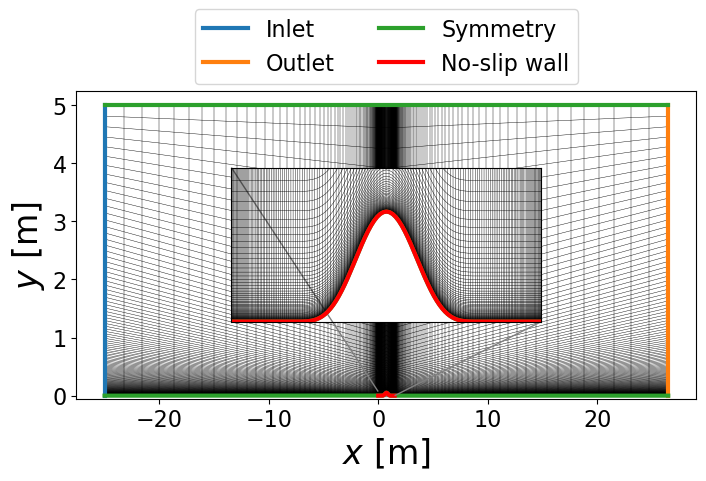

In [13]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

ni, nj, nk = data_dict['x'].shape

figsize = (8, 4)
lw = 0.3

fig, ax = plt.subplots(figsize=figsize)

skip = 1
for i in range(0, ni, skip):
    ax.plot(data_dict['x'][i,:,0], data_dict['y'][i,:,0], 'k-', linewidth=lw)

for j in range(0, nj, skip):
    ax.plot(data_dict['x'][:,j,0], data_dict['y'][:,j,0], 'k-', linewidth=lw)

ax.plot(data_dict['x'][0,:,0], data_dict['y'][0,:,0], 'C0-', linewidth=3, label='Inlet')
ax.plot(data_dict['x'][-1,:,0], data_dict['y'][-1,:,0], 'C1-', linewidth=3, label='Outlet')
ax.plot(data_dict['x'][:,0,0], data_dict['y'][:,0,0], 'C2-', linewidth=3, label='Symmetry')
ax.plot(data_dict['x'][:,-1,0], data_dict['y'][:,-1,0], 'C2-', linewidth=3)
ax.plot(data_dict['x'][97:257,0,0], data_dict['y'][97:257,0,0],
        'r-', linewidth=3, label='No-slip wall')

# ---- inset ----
axins = inset_axes(
    ax,
    width="50%",      # inset size
    height="50%",
    loc="center"
)

for i in range(0, ni, skip):
    axins.plot(data_dict['x'][i,:,0], data_dict['y'][i,:,0], 'k-', linewidth=lw)

for j in range(0, nj, skip):
    axins.plot(data_dict['x'][:,j,0], data_dict['y'][:,j,0], 'k-', linewidth=lw)

axins.plot(data_dict['x'][0,:,0], data_dict['y'][0,:,0], 'C0-', linewidth=3)
axins.plot(data_dict['x'][-1,:,0], data_dict['y'][-1,:,0], 'C1-', linewidth=3)
axins.plot(data_dict['x'][:,0,0], data_dict['y'][:,0,0], 'C2-', linewidth=3)
axins.plot(data_dict['x'][:,-1,0], data_dict['y'][:,-1,0], 'C2-', linewidth=3)
axins.plot(data_dict['x'][97:257,0,0], data_dict['y'][97:257,0,0],
           'r-', linewidth=3)

# zoom region
axins.set_xlim(0.0, 1.5)
axins.set_ylim(0.0, 0.07)

axins.set_xticks([])
axins.set_yticks([])

# draw rectangle + connectors
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

ax.legend(ncol=2, bbox_to_anchor=(0.5, 1.3), loc='upper center')
ax.set_xlabel(r'$x$ [m]')
ax.set_ylabel(r'$y$ [m]')
ax.set_ylim(bottom=-0.05)

plt.savefig('nasabump_grid.pdf', bbox_inches='tight')
plt.show()